In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

## Estimacion Basica (Vainilla)

#### cargar datos

In [2]:
data = pd.read_csv("../data/casas-california.csv")
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


#### visualizar casa de california

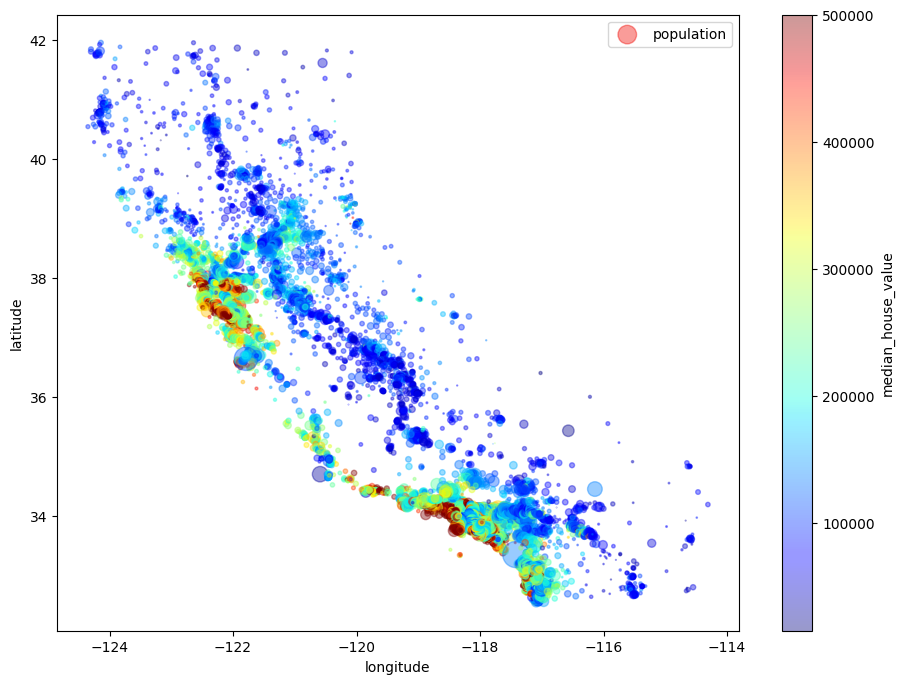

In [3]:
data.plot(kind ="scatter", x ="longitude", y ="latitude", alpha = 0.4,
             s = data["population"] / 100, label ="population", figsize =(11,8),
             c ="median_house_value", cmap = plt.get_cmap("jet"), colorbar = True, ) 
plt.legend()

#### correlaciones

In [ ]:
### EJERCICIO: (1pt) 
# utilize matplotlib para desplegar la matriz de correlaciones

corr = data.corr()

# Desplegar la matriz de correlaciones con pandas
corr.style.background_gradient(cmap='plasma').set_precision(2)

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   
ocean_proximity           NaN       NaN                 NaN          NaN   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude 

In [ ]:
### EJERCICIO: (1pt) 
# despliegue las correlaciones de la variable median_house_value
corr["median_house_value"].sort_values(ascending=False)

#### limpieza de datos

In [ ]:
### EJERCICIO: (1pt)
# utilize seaborn para revisar de que no hay valores en blanco. despliegue el grafico de seaborn.

data['total_bedrooms'] = data['total_bedrooms'].fillna(data['total_bedrooms'].median())

sns.heatmap(data.isnull(), cbar=False)

In [ ]:
### EJERCICIO: (1pt)
# Revise los tipos de las columnas y verifique que cada uno esta definido correctamente 
# (ejemplo, la variable OCEAN_PROXIMITY debe ser categorica)

enc = OrdinalEncoder()
enc.fit(data[["ocean_proximity"]])
data[["ocean_proximity"]] = enc.transform(data[["ocean_proximity"]])

#### test & training set

In [ ]:
### EJERCICIO: (1pt) 
# separe el dataset train:80%, test:20%, random_state=42 
# donde y = median_house_value

y = data.median_house_value
X = data.loc[:, data.columns != 'median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

#### regresion lineal multiple

In [19]:
### EJERCICIO: (1pt)
# estime el modelo de regresion lineal utilizando Sklearn.
# imprima los coeficientes

model = LinearRegression().fit(X.values, y.values)

print("Coeficientes:")
print("b",0,":","%.2f"%model.intercept_)
for i,b in zip(np.arange(1,len(model.coef_)+1), model.coef_):
    print("b",i,":", "%.2f"%b)

ValueError: could not convert string to float: 'NEAR BAY'

In [ ]:
### EJERCICIO: (1pt)
# utilize statsmodels para estimar las estadisticas del modelo actual.
# estime el MSE del train/test

y_prima_train = model.predict(X_train)
mse_train = mean_squared_error(y_train, y_prima_train)

y_prima_test = model.predict(X_test)
mse_test = mean_squared_error(y_test, y_prima_test)


print("MSE Train:",np.sqrt(mse_train))
print(" MSE Test:",np.sqrt(mse_test))

print("\n"*2)

model_ols = sm.OLS(y_train, sm.add_constant(X_train))
pred = model_ols.fit()
print(pred.summary())

## Estimacion Avanzada - Feature Engineering

En este momento, ud acaba de realizar la estimación del modelo más básico, sin aplicar transformaciones, ni escalamientos a las variables. 

**Aqui es donde se pone bonito...**

En esta sección debe estudiar las variables, sus distribuciones, para identificar qué tipo de cosas se pueden realizar para mejorar el modelo. Vuelva a calcular las estadísticas del modelo (antes y después) para que tenga un punto de referencia.

Algunas recomendaciones:
- Trate de comprender el rol de la variable en la prediccion. Tiene sentido?
- Algunos modelos trabajan mejor con menos variables. (aqui puede agregar o remover variables)
- Aplique transformaciones para "normalizar" variables (que tengan una distribucion quasi-normal)
- considere crear nuevas variables de ser necesario: por ejemplo bedrooms_per_room = data["total_bedrooms"] / data["total_rooms"]

In [ ]:
### EJERCICIO: (1pt)
# Aplique Escalamiento y Transformaciones

# seleccion de variables
data2 = data.loc[::, ['median_income', 'longitude', 'latitude', 'median_house_value','housing_median_age']]

# variable categorica
dummies = pd.get_dummies(data.ocean_proximity, prefix="OP")
data2 = data2.join(dummies)

# se crean nuevas variables
data2["households_per_population"] = data["households"] / data["population"]
data2["bedrooms_per_total_rooms"] = data["total_bedrooms"] / data["total_rooms"]

In [ ]:
### EJERCICIO: (1pt)
# Estime nuevamente el modelo de regresion lineal

y = data2.median_house_value
X = data2.loc[:, data2.columns != 'median_house_value']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

model = LinearRegression().fit(X, y.values)

print("Coeficientes:")
print("b",0,":","%.2f"%model.intercept_)
for i,b in zip(np.arange(1,len(model.coef_)+1), model.coef_):
    print("b",i,":", "%.2f"%b)

In [ ]:
corr = data2.corr()

# Desplegar la matriz de correlaciones con pandas
corr.style.background_gradient(cmap='plasma').set_precision(2)

In [ ]:
corr["median_house_value"].sort_values(ascending=False)

In [ ]:
### EJERCICIO: (1pt)
# Calcule nuevamente las estadisticas para determinar si hay mejoras sobre el modelo.
# estime el MSE del train/test

y_prima_train = model.predict(X_train)
mse_train = mean_squared_error(y_train, y_prima_train)

y_prima_test = model.predict(X_test)
mse_test = mean_squared_error(y_test, y_prima_test)


print("MSE Train:",np.sqrt(mse_train))
print(" MSE Test:",np.sqrt(mse_test))

print("\n"*2)

model_ols = sm.OLS(y_train, sm.add_constant(X_train))
pred = model_ols.fit()
print(pred.summary())

In [ ]:
# Prueba con Arboles de Regression con K-Fold Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor(random_state=0)
scores = cross_val_score(regressor, X_train, y_train, cv=10, scoring="neg_mean_squared_error")
scores = np.sqrt(-scores)

scores.mean()